In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import itertools
import warnings
warnings.filterwarnings('ignore')

In [4]:
def read_cococonet(file_location):
    """[Takes a species name in any format, and returns a CoCoConet for that species]

    Args:
        species_1 ([str]): [Species in CoCoCoNet]

    Returns:
        [Panda Dataframe]: [GenexGene Matrix]
    """
    import h5py
    import pandas as pd





    file_location = file_location

    net = h5py.File(file_location,'r')
    agg_dataset = net['agg'] 
    row_dataset = net['row']
    col_dataset = net['col']
    row_gene_list = []
    for gene in row_dataset:
        row_gene_list.append(gene.decode('UTF-8'))
    col_gene_list = []
    for gene in col_dataset: 
        col_gene_list.append(gene.decode('UTF-8'))
    net_df = pd.DataFrame(data = agg_dataset[:,:], index = row_gene_list, columns = col_gene_list)
    net.close()
    return net_df 

In [11]:
tomato_net = read_cococonet('C:\\Users\\mikep\\Data\\Data_for_review\\tomato_prioAggNet.hdf5')
tomato_net

,GAD3,LOC101263636,sos1,LOC101263144,LOC101247154,LOC101262550,LOC101261948,LOC101246854,LOC101261647,LOC101261146,...,LyesC2t007,LyesC2t008,LyesC2t010,LyesC2t011,LyesC2t014,LyesC2t018,LyesC2t021,LyesC2t022,LyesC2t024,LyesC2t025
GAD3,1.000000,0.689098,0.727656,0.497842,0.012661,0.591291,0.658163,0.117947,0.762342,0.380569,...,0.090074,0.136404,0.065551,0.103539,0.134292,0.173176,0.177203,0.070245,0.086475,0.094361
LOC101263636,0.689098,1.000000,0.667752,0.501023,0.212098,0.636482,0.824174,0.073736,0.836330,0.352467,...,0.127138,0.230505,0.252457,0.202720,0.261291,0.297037,0.263904,0.221912,0.357406,0.280307
sos1,0.727656,0.667752,1.000000,0.994842,0.141992,0.790989,0.974383,0.267649,0.961738,0.763919,...,0.004127,0.045253,0.025724,0.047999,0.043161,0.016229,0.093901,0.012710,0.033183,0.023315
LOC101263144,0.497842,0.501023,0.994842,1.000000,0.187615,0.561807,0.876529,0.352872,0.940175,0.785507,...,0.018152,0.024460,0.014259,0.017756,0.034138,0.021386,0.071531,0.005753,0.021741,0.032257
LOC101247154,0.012661,0.212098,0.141992,0.187615,1.000000,0.433898,0.165261,0.095748,0.092793,0.382251,...,0.047774,0.118207,0.034440,0.027876,0.090734,0.049684,0.103165,0.028425,0.032232,0.019869
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LyesC2t018,0.173176,0.297037,0.016229,0.021386,0.049684,0.111536,0.106422,0.093669,0.188904,0.017689,...,0.492075,0.489830,0.512068,0.558388,0.474744,1.000000,0.548326,0.593247,0.598913,0.585383
LyesC2t021,0.177203,0.263904,0.093901,0.071531,0.103165,0.269847,0.153390,0.162583,0.277404,0.202697,...,0.599663,0.460649,0.544274,0.601073,0.507052,0.548326,1.000000,0.681204,0.625740,0.673094
LyesC2t022,0.070245,0.221912,0.012710,0.005753,0.028425,0.113443,0.064566,0.095528,0.149526,0.054449,...,0.672771,0.415112,0.620948,0.681745,0.547146,0.593247,0.681204,1.000000,0.736235,0.670794
LyesC2t024,0.086475,0.357406,0.033183,0.021741,0.032232,0.087477,0.099854,0.077216,0.150259,0.043632,...,0.699531,0.534180,0.636299,0.651266,0.592425,0.598913,0.625740,0.736235,1.000000,0.677407


In [7]:
arabi_net = read_cococonet('G:\\My Drive\\Cross_computer_data\\arabidopsis_prioAggNet.hdf5')
arabi_net

,AT1G01020,AT1G01030,AT1G01040,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,AT1G01100,AT1G01110,...,ATCG01070,ATCG01080,ATCG01090,ATCG01100,ATCG01110,ATCG01120,ATCG01130,ATCG01180,ATCG01210,ATCG01310
AT1G01020,1.000000,0.676041,0.885107,0.916603,0.167027,0.625596,0.801175,0.866369,0.954286,0.715750,...,0.111731,0.193853,0.261697,0.299060,0.321617,0.287853,0.559907,0.017205,0.011806,0.091015
AT1G01030,0.676041,1.000000,0.707718,0.515532,0.420354,0.292083,0.687003,0.626281,0.483536,0.570675,...,0.245167,0.215414,0.255414,0.306986,0.308402,0.270118,0.463394,0.083490,0.059014,0.108780
AT1G01040,0.885107,0.707718,1.000000,0.836387,0.545101,0.701558,0.656258,0.857046,0.657204,0.650843,...,0.155183,0.230038,0.149740,0.334558,0.287951,0.186425,0.219380,0.032348,0.018332,0.057761
AT1G01050,0.916603,0.515532,0.836387,1.000000,0.562112,0.726964,0.837948,0.928252,0.952045,0.640223,...,0.089440,0.177388,0.164935,0.236661,0.251851,0.213062,0.412583,0.046082,0.029016,0.086736
AT1G01060,0.167027,0.420354,0.545101,0.562112,1.000000,0.327202,0.242215,0.304953,0.217415,0.077569,...,0.082518,0.125455,0.103488,0.187982,0.195059,0.125488,0.212731,0.061676,0.057518,0.044208
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ATCG01120,0.287853,0.270118,0.186425,0.213062,0.125488,0.083681,0.364707,0.333718,0.237716,0.149145,...,0.858389,0.905572,0.926062,0.941864,0.954421,1.000000,0.969018,0.450607,0.357960,0.410586
ATCG01130,0.559907,0.463394,0.219380,0.412583,0.212731,0.077222,0.625678,0.496059,0.428496,0.226147,...,0.881835,0.936241,0.946935,0.958553,0.960399,0.969018,1.000000,0.467233,0.412343,0.483002
ATCG01180,0.017205,0.083490,0.032348,0.046082,0.061676,0.022381,0.090228,0.069825,0.028903,0.015799,...,0.751869,0.781811,0.740045,0.745181,0.676666,0.450607,0.467233,1.000000,0.999090,0.579657
ATCG01210,0.011806,0.059014,0.018332,0.029016,0.057518,0.026014,0.062831,0.043944,0.015468,0.018706,...,0.687306,0.710940,0.676507,0.687223,0.567304,0.357960,0.412343,0.999090,1.000000,0.511263


In [10]:
nm_map = pd.read_csv('C:\\Users\\mikep\\Data\\Data_for_review\\tomato_to_arabidopsis_ortholog_NM.csv')
nm_map

,tomato OrthoGene,arabidopsis OrthoGene,Orthogroup,tomato Symbol,arabidopsis Symbol
0,4081_0:002534,3702_0:006584,10009at3193,LOC101245541,AT5G42200
1,4081_0:0062c9,3702_0:006584,10009at3193,LOC101249449,AT5G42200
2,4081_0:0044e5,3702_0:001f5f,10092at3193,GPA1,AT2G26300
3,4081_0:0060db,3702_0:000e32,10147at3193,LOC101260909,AT1G73910
4,4081_0:0060db,3702_0:0018a2,10147at3193,LOC101260909,AT1G18450
...,...,...,...,...,...
53425,4081_0:003f8c,3702_0:003134,9942at3193,LOC101261051,AT3G59920
53426,4081_0:005b8a,3702_0:003134,9942at3193,LOC101259410,AT3G59920
53427,4081_0:000a73,3702_0:005540,9942at3193,GDI1,AT5G09550
53428,4081_0:003f8c,3702_0:005540,9942at3193,LOC101261051,AT5G09550


In [42]:
shuffled_nm_map= nm_map.copy()
shuffled_nm_map['arabidopsis Symbol'] = shuffled_nm_map['arabidopsis Symbol'].sample(frac=1).values
shuffled_nm_map

,tomato OrthoGene,arabidopsis OrthoGene,Orthogroup,tomato Symbol,arabidopsis Symbol
0,4081_0:002534,3702_0:006584,10009at3193,LOC101245541,AT1G13300
1,4081_0:0062c9,3702_0:006584,10009at3193,LOC101249449,AT4G00680
2,4081_0:0044e5,3702_0:001f5f,10092at3193,GPA1,AT4G01070
3,4081_0:0060db,3702_0:000e32,10147at3193,LOC101260909,AT5G53090
4,4081_0:0060db,3702_0:0018a2,10147at3193,LOC101260909,AT3G61280
...,...,...,...,...,...
53425,4081_0:003f8c,3702_0:003134,9942at3193,LOC101261051,AT4G21534
53426,4081_0:005b8a,3702_0:003134,9942at3193,LOC101259410,AT1G29640
53427,4081_0:000a73,3702_0:005540,9942at3193,GDI1,AT5G12970
53428,4081_0:003f8c,3702_0:005540,9942at3193,LOC101261051,AT5G19980


In [43]:
nm_map

,tomato OrthoGene,arabidopsis OrthoGene,Orthogroup,tomato Symbol,arabidopsis Symbol
0,4081_0:002534,3702_0:006584,10009at3193,LOC101245541,AT5G42200
1,4081_0:0062c9,3702_0:006584,10009at3193,LOC101249449,AT5G42200
2,4081_0:0044e5,3702_0:001f5f,10092at3193,GPA1,AT2G26300
3,4081_0:0060db,3702_0:000e32,10147at3193,LOC101260909,AT1G73910
4,4081_0:0060db,3702_0:0018a2,10147at3193,LOC101260909,AT1G18450
...,...,...,...,...,...
53425,4081_0:003f8c,3702_0:003134,9942at3193,LOC101261051,AT3G59920
53426,4081_0:005b8a,3702_0:003134,9942at3193,LOC101259410,AT3G59920
53427,4081_0:000a73,3702_0:005540,9942at3193,GDI1,AT5G09550
53428,4081_0:003f8c,3702_0:005540,9942at3193,LOC101261051,AT5G09550


In [44]:
shuffled_nm_map.to_csv('C:\\Users\\mikep\\Data\\Data_for_review\\shuffled_nm_map.csv', index=False)


In [6]:
tomato_net

,Solyc00g500062.1,Solyc00g500063.1,Solyc00g500064.1,Solyc00g500065.1,Solyc00g500066.1,Solyc00g500095.1,Solyc00g500103.1,Solyc00g500140.1,Solyc00g118690.1,Solyc00g014850.1,...,Solyc12g100240.1,Solyc12g100250.3,Solyc12g100260.1,Solyc12g100270.2,Solyc12g100280.3,Solyc12g100290.3,Solyc12g100310.2,Solyc12g100320.2,Solyc12g100330.2,Solyc12g100360.1
Solyc00g500062.1,1.000000,0.976321,0.816370,0.905470,0.841128,0.023169,0.325780,0.539502,0.385391,0.428264,...,0.013020,0.021773,0.019113,0.022066,0.236551,0.364181,0.247544,0.304198,0.173364,0.253347
Solyc00g500063.1,0.976321,1.000000,0.826647,0.965459,0.866005,0.009771,0.459150,0.585682,0.447222,0.559993,...,0.023020,0.009705,0.010752,0.008385,0.346829,0.411344,0.282143,0.332191,0.240914,0.238565
Solyc00g500064.1,0.816370,0.826647,1.000000,0.647015,0.606216,0.178147,0.327039,0.581324,0.380336,0.440379,...,0.143144,0.145320,0.113124,0.118826,0.448442,0.582122,0.508989,0.412206,0.613273,0.494836
Solyc00g500065.1,0.905470,0.965459,0.647015,1.000000,0.880330,0.020723,0.508068,0.277599,0.463220,0.640390,...,0.020838,0.021698,0.022983,0.047275,0.080209,0.299352,0.145689,0.297222,0.067437,0.243518
Solyc00g500066.1,0.841128,0.866005,0.606216,0.880330,1.000000,0.024356,0.415310,0.287690,0.380225,0.474305,...,0.006459,0.009302,0.008292,0.012104,0.099396,0.120391,0.042262,0.093789,0.042159,0.062162
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Solyc12g100290.3,0.364181,0.411344,0.582122,0.299352,0.120391,0.138739,0.110981,0.146552,0.149642,0.239410,...,0.143262,0.121082,0.121868,0.401912,0.406517,1.000000,0.884281,0.833189,0.755417,0.930516
Solyc12g100310.2,0.247544,0.282143,0.508989,0.145689,0.042262,0.130733,0.096674,0.068035,0.133714,0.224064,...,0.314901,0.370198,0.315773,0.519404,0.203410,0.884281,1.000000,0.958287,0.969937,0.988432
Solyc12g100320.2,0.304198,0.332191,0.412206,0.297222,0.093789,0.068643,0.261379,0.128240,0.290589,0.331309,...,0.308854,0.320017,0.355811,0.449749,0.072674,0.833189,0.958287,1.000000,0.747459,0.928079
Solyc12g100330.2,0.173364,0.240914,0.613273,0.067437,0.042159,0.074176,0.053560,0.092939,0.060147,0.190135,...,0.266965,0.214953,0.224670,0.445162,0.350417,0.755417,0.969937,0.747459,1.000000,0.796322


In [23]:
def Calculate_Score_list_for_thresholding(
    network_1,
    network_2,
    cross_species_n_m_genes_path,
    Species_1="rice",
    Species_2="maize",
):
    import pandas as pd

    # Get Species Names in Common form
    common_name_1 = Species_1
    common_name_2 = Species_2


    cross_species_n_m_genes = pd.read_csv(cross_species_n_m_genes_path)
    orig_column_common_name_1 = common_name_1 + " Symbol"
    orig_column_common_name_2 = common_name_2 + " Symbol"
    cross_species_n_m_genes = cross_species_n_m_genes.rename(
        columns={
            orig_column_common_name_1: common_name_1,
            orig_column_common_name_2: common_name_2,
        }
    )
    ### Get one to ones
    cross_species_map_one_to_one = cross_species_n_m_genes.drop_duplicates(
        subset=common_name_1,
        keep=False,
    )
    cross_species_map_one_to_one = cross_species_map_one_to_one.drop_duplicates(
        subset=common_name_2, keep=False
    )

    ## Convert to Dictionary
    dictionary_mapper_one_to_two = cross_species_map_one_to_one.set_index(
        common_name_1
    ).to_dict()[common_name_2]
    dictionary_mapper_dos_to_uno = cross_species_map_one_to_one.set_index(
        common_name_2
    ).to_dict()[common_name_1]

    ## Read In Cococonets
    coconet_species_one = network_1
    coconet_species_two = network_2

    cross_species_n_m_genes["Group ID"] = "Unassigned"

    ## Assign Genes to Groups
    id_indexer = 0
    for gene_pair in cross_species_n_m_genes.iterrows():

        if gene_pair[1]["Group ID"] == "Unassigned":
            current_species_1_gene = gene_pair[1][common_name_1]
            current_species_2_gene = gene_pair[1][common_name_2]
            cross_species_n_m_genes["Group ID"].loc[
                (cross_species_n_m_genes[common_name_1] == current_species_1_gene)
                & (cross_species_n_m_genes["Group ID"] == "Unassigned")
            ] = id_indexer
            cross_species_n_m_genes["Group ID"].loc[
                (cross_species_n_m_genes[common_name_2] == current_species_2_gene)
                & (cross_species_n_m_genes["Group ID"] == "Unassigned")
            ] = id_indexer

            all_labeled_groups = cross_species_n_m_genes.loc[
                cross_species_n_m_genes["Group ID"] == id_indexer
            ]

            all_labeled_groups_species_1_genes = all_labeled_groups[
                common_name_1
            ].to_list()
            all_labeled_groups_species_2_genes = all_labeled_groups[
                common_name_2
            ].to_list()

            cross_species_n_m_genes["Group ID"].loc[
                cross_species_n_m_genes[common_name_1].isin(
                    all_labeled_groups_species_1_genes
                )
            ] = id_indexer
            cross_species_n_m_genes["Group ID"].loc[
                cross_species_n_m_genes[common_name_2].isin(
                    all_labeled_groups_species_2_genes
                )
            ] = id_indexer

            id_indexer += 1

    # Identify Pairs for evaluation
    all_pairs_to_evaluate_for_functional_conservation = pd.DataFrame(
        columns=[common_name_1, common_name_2, "Group Number"]
    )
    for group_number in list(set(cross_species_n_m_genes["Group ID"].to_list())):
        current_gene_map = cross_species_n_m_genes.loc[
            cross_species_n_m_genes["Group ID"] == group_number
        ]
        list_of_species_1_genes_in_group = list(
            set(current_gene_map[common_name_1].to_list())
        )
        list_of_species_2_genes_in_group = list(
            set(current_gene_map[common_name_2].to_list())
        )
        all_combo_list_current_genes = itertools.product(
            list_of_species_1_genes_in_group, list_of_species_2_genes_in_group
        )
        all_combo_list_current_genes = list(map(list, all_combo_list_current_genes))
        current_list_of_pairs = pd.DataFrame(
            all_combo_list_current_genes, columns=[common_name_1, common_name_2]
        )
        current_list_of_pairs["Group Number"] = group_number
        all_pairs_to_evaluate_for_functional_conservation = pd.concat(
            [all_pairs_to_evaluate_for_functional_conservation, current_list_of_pairs]
        )

    all_pairs_to_evaluate_for_functional_conservation["Species 1 Score"] = np.nan
    all_pairs_to_evaluate_for_functional_conservation["Species 2 Score"] = np.nan

    ## Trim cococonets to match

    trimmed_species_1_cococonet = coconet_species_one[
        coconet_species_one.columns.intersection(
            cross_species_n_m_genes[common_name_1].to_list()
        )
    ]
    trimmed_species_1_cococonet = trimmed_species_1_cococonet[
        trimmed_species_1_cococonet.index.isin(
            cross_species_n_m_genes[common_name_1].to_list()
        )
    ]
    double_species_1_trimmed_cococonet = trimmed_species_1_cococonet[
        trimmed_species_1_cococonet.columns.intersection(
            cross_species_map_one_to_one[common_name_1].to_list()
        )
    ]
    double_species_1_trimmed_cococonet = double_species_1_trimmed_cococonet.replace(
        1, 0
    )

    trimmed_species_2_cococonet = coconet_species_two[
        coconet_species_two.columns.intersection(
            cross_species_n_m_genes[common_name_2].to_list()
        )
    ]
    trimmed_species_2_cococonet = trimmed_species_2_cococonet[
        trimmed_species_2_cococonet.index.isin(
            cross_species_n_m_genes[common_name_2].to_list()
        )
    ]
    double_species_2_trimmed_cococonet = trimmed_species_2_cococonet[
        trimmed_species_2_cococonet.columns.intersection(
            cross_species_map_one_to_one[common_name_2].to_list()
        )
    ]
    double_species_2_trimmed_cococonet = double_species_2_trimmed_cococonet.replace(
        1, 0
    )

    ## Rank
    species_1_cococonet_ranked = trimmed_species_1_cococonet.rank()
    species_2_cococonet_ranked = trimmed_species_2_cococonet.rank()

    # Do top 10 Genes
    top_10_species_1_genes = np.array(
        [
            double_species_1_trimmed_cococonet.T[c].nlargest(10).index.values
            for c in double_species_1_trimmed_cococonet.T
        ]
    )  # using pair list above, cut down top 10 list to relevant genes, probably by adding list as a column in panda and then filtering panda to index of pair list
    top_10_species_1_genes_dataframe = pd.DataFrame(
        data=top_10_species_1_genes,
        index=double_species_1_trimmed_cococonet.index,
        columns=[
            "One",
            "Two",
            "Three",
            "Four",
            "Five",
            "Six",
            "Seven",
            "Eight",
            "Nine",
            "Ten",
        ],
    )

    # Convert
    top_10_species_1_genes_as_species_2 = top_10_species_1_genes_dataframe.replace(
        to_replace=dictionary_mapper_one_to_two
    )

    # Get genes for checking
    have_species_1_pairs = all_pairs_to_evaluate_for_functional_conservation.loc[
        all_pairs_to_evaluate_for_functional_conservation[common_name_1].isin(
            top_10_species_1_genes_as_species_2.index
        )
    ]
    trimmed_all_gene_pairs_for_fc = have_species_1_pairs.loc[
        have_species_1_pairs[common_name_2].isin(trimmed_species_2_cococonet.index)
    ]
    trimmed_all_gene_pairs_for_fc = trimmed_all_gene_pairs_for_fc.reset_index(drop=True)

    # Get values in species 2
    for two_genes in trimmed_all_gene_pairs_for_fc.iterrows():
        current_species_1_gene = two_genes[1][common_name_1]
        current_species_2_gene = two_genes[1][common_name_2]
        finger_print_genes = top_10_species_1_genes_as_species_2.loc[
            current_species_1_gene
        ].to_list()
        gene_ranks_in_species_2 = species_2_cococonet_ranked.loc[
            species_2_cococonet_ranked.index.isin(finger_print_genes),
            current_species_2_gene,
        ]
        avg_rank_in_species_2 = gene_ranks_in_species_2.mean()
        index_from_pairs = two_genes[0]
        trimmed_all_gene_pairs_for_fc.at[index_from_pairs, "Species 1 Score"] = (
            avg_rank_in_species_2
        )

    # Repeat for Species 2

    top_10_species_2_genes = np.array(
        [
            double_species_2_trimmed_cococonet.T[c].nlargest(10).index.values
            for c in double_species_2_trimmed_cococonet.T
        ]
    )  # using pair list above, cut down top 10 list to relevant genes, probably by adding list as a column in panda and then filtering panda to index of pair list
    top_10_species_2_genes_dataframe = pd.DataFrame(
        data=top_10_species_2_genes,
        index=double_species_2_trimmed_cococonet.index,
        columns=[
            "One",
            "Two",
            "Three",
            "Four",
            "Five",
            "Six",
            "Seven",
            "Eight",
            "Nine",
            "Ten",
        ],
    )

    # convert
    top_10_species_2_genes_as_species_1 = top_10_species_2_genes_dataframe.replace(
        to_replace=dictionary_mapper_dos_to_uno
    )

    # Get values in species 1
    for two_genes in trimmed_all_gene_pairs_for_fc.iterrows():
        current_species_1_gene = two_genes[1][common_name_1]
        current_species_2_gene = two_genes[1][common_name_2]
        finger_print_genes = top_10_species_2_genes_as_species_1.loc[
            current_species_2_gene
        ].to_list()
        gene_ranks_in_species_1 = species_1_cococonet_ranked.loc[
            species_1_cococonet_ranked.index.isin(finger_print_genes),
            current_species_1_gene,
        ]
        avg_rank_in_species_1 = gene_ranks_in_species_1.mean()
        index_from_pairs = two_genes[0]
        trimmed_all_gene_pairs_for_fc.loc[index_from_pairs, "Species 2 Score"] = (
            avg_rank_in_species_1
        )

    # Caluclate Divisors
    Number_of_species_1_genes = len(top_10_species_1_genes_as_species_2)
    Number_of_species_2_genes = len(top_10_species_2_genes_as_species_1)

    species_1_score_divisor = Number_of_species_2_genes - 4.5
    species_2_score_divisor = Number_of_species_1_genes - 4.5

    # Divide and Average
    trimmed_all_gene_pairs_for_fc["Species 1 Score"] = (
        trimmed_all_gene_pairs_for_fc["Species 1 Score"] / species_1_score_divisor
    )
    trimmed_all_gene_pairs_for_fc["Species 2 Score"] = (
        trimmed_all_gene_pairs_for_fc["Species 2 Score"] / species_2_score_divisor
    )
    trimmed_all_gene_pairs_for_fc["Total Score"] = trimmed_all_gene_pairs_for_fc[
        ["Species 1 Score", "Species 2 Score"]
    ].mean(axis=1)

    return trimmed_all_gene_pairs_for_fc

In [30]:
orthogroups_with_scores = Calculate_Score_list_for_thresholding(
    network_1=arabi_net,
    network_2=tomato_net,
    cross_species_n_m_genes_path='C:\\Users\\mikep\\Data\\Data_for_review\\tomato_to_arabidopsis_ortholog_NM.csv',
    Species_1="arabidopsis",
    Species_2="tomato",
)

In [31]:
orthogroups_with_scores.to_csv('C:\\Users\\mikep\\Data\\Data_for_review\\orthogroups_with_scores.csv', index=True)


In [45]:
shuffled_og_with_scores = Calculate_Score_list_for_thresholding(
    network_1=arabi_net,
    network_2=tomato_net,
    cross_species_n_m_genes_path='C:\\Users\\mikep\\Data\\Data_for_review\\shuffled_nm_map.csv',
    Species_1="arabidopsis",
    Species_2="tomato",
)

In [46]:
shuffled_og_with_scores.to_csv('C:\\Users\\mikep\\Data\\Data_for_review\\shuffled_orthogroups_with_scores.csv', index=True)

In [47]:
orthogroups_with_scores['Type'] = 'Orthogroup'
shuffled_og_with_scores['Type'] = 'Shuffled'

In [48]:
orthogroups_with_scores

,arabidopsis,tomato,Group Number,Species 1 Score,Species 2 Score,Total Score,Type
0,AT5G42200,LOC101249449,0,0.550162,0.811544,0.680853,Orthogroup
1,AT5G42200,LOC101245541,0,0.627618,0.705853,0.666736,Orthogroup
2,AT2G26300,GPA1,2,0.790853,0.847778,0.819316,Orthogroup
3,AT1G18450,LOC101260909,3,0.932388,0.908913,0.920651,Orthogroup
4,AT1G73910,LOC101260909,3,0.718688,0.722911,0.720800,Orthogroup
...,...,...,...,...,...,...,...
39618,AT3G47400,LOC101260871,32050,0.775888,0.639240,0.707564,Orthogroup
39619,AT3G47400,LOC101258375,32050,0.730356,0.773001,0.751678,Orthogroup
39620,AT3G47400,LOC101260197,32050,0.917318,0.644712,0.781015,Orthogroup
39621,AT3G47400,PE1,32050,0.296960,0.490193,0.393576,Orthogroup


In [49]:
shuffled_og_with_scores

,arabidopsis,tomato,Group Number,Species 1 Score,Species 2 Score,Total Score,Type
0,AT3G53470,LOC101252996,0,0.586381,0.489378,0.537879,Shuffled
1,AT3G53470,LOC101245541,0,0.495225,0.564238,0.529732,Shuffled
2,AT3G53470,ACS3,0,0.429257,0.610026,0.519641,Shuffled
3,AT1G04120,LOC101252996,0,0.435461,0.562266,0.498863,Shuffled
4,AT1G04120,LOC101245541,0,0.372374,0.469842,0.421108,Shuffled
...,...,...,...,...,...,...,...
153546,AT4G25260,LOC101245007,32744,0.731419,0.456203,0.593811,Shuffled
153547,AT4G21390,cycD3,32744,0.624399,0.524792,0.574595,Shuffled
153548,AT4G21390,LOC101245007,32744,0.395866,0.529343,0.462605,Shuffled
153549,AT5G04020,cycD3,32744,0.553878,0.539812,0.546845,Shuffled


In [50]:
combined_scores = pd.concat([orthogroups_with_scores, shuffled_og_with_scores], ignore_index=True)

<Axes: xlabel='Total Score', ylabel='Count'>

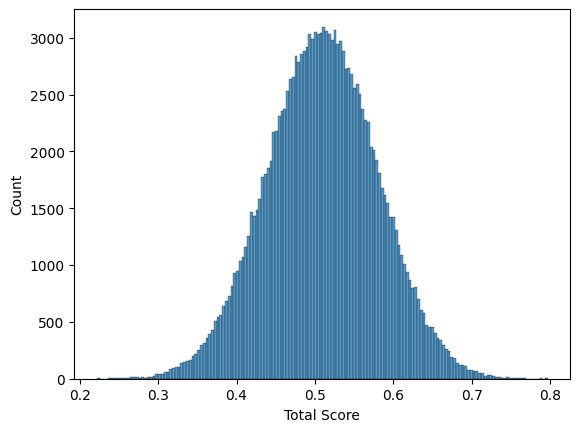

In [51]:
sns.histplot(x = shuffled_og_with_scores['Total Score'])

<Axes: xlabel='Total Score', ylabel='Density'>

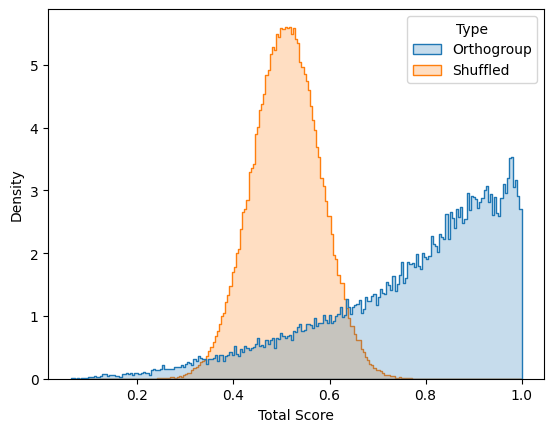

In [52]:
sns.histplot(data = combined_scores, x = "Total Score", hue = "Type", element="step", stat="density", common_norm=False)